# Building the Linear Regression Model - Lena Sophie

## Step 1: Importing

In [2]:
# import the libraries
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Statistical modelling
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Train/test splitting and validation
from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    GroupKFold,
    cross_validate
)

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
# import the datasets
stations = pd.read_csv("../data/raw/stations_for_route_generation_final.csv")
ontd_segments = pd.read_csv("../data/raw/ontd_segments_germany.csv")
compositions = pd.read_csv("../data/raw/compositions_for_energy_model.csv")
energy = pd.read_csv("../data/processed/trassenfinder_energy_results.csv")


In [4]:
# inspection

print(energy.shape)
print(energy.columns)

print(ontd_segments.shape)
print(ontd_segments.columns)

print(compositions.shape)
print(compositions.columns)

(448, 13)
Index(['route_name', 'start_stop_name', 'start_ds100', 'end_stop_name',
       'end_ds100', 'composition_id', 'n_coaches', 'weight_t', 'length_m',
       'v_max_kmh', 'energy_kwh', 'distance_km', 'travel_time_min'],
      dtype='str')
(96, 11)
Index(['route_name', 'all_routes_serving_segment', 'start_stop_id',
       'start_stop_name', 'start_ds100', 'end_stop_id', 'end_stop_name',
       'end_ds100', 'travel_duration_min', 'air_distance_km',
       'n_trip_occurrences'],
      dtype='str')
(8, 18)
Index(['composition_id', 'description', 'material_strategy', 'n_coaches',
       'total_places', 'places_by_class', 'loco_name', 'loco_baureihe',
       'trassenfinder_triebfahrzeug_hauptnummer', 'loco_weight_t',
       'loco_length_m', 'v_max_kmh', 'coaches_length_m_wagenzuglaenge',
       'coaches_net_weight_t', 'pax_load_80pct_t',
       'coaches_gross_weight_80pct_t_wagenzugmasse',
       'coaches_gross_weight_100pct_t', 'total_weight_incl_loco_80pct_t'],
      dtype='str')


## Step 2: Building the dataset for regression

In [5]:
# merge the dataframes

data = (
    energy
    .merge(
        ontd_segments,
        on=[
            "route_name",
            "start_ds100",
            "end_ds100"
        ],
        how="left",
        suffixes=("", "_segment")
    )
    .merge(
        compositions,
        on="composition_id",
        how="left",
        suffixes=("", "_composition")
    )
)

In [6]:
# verify the merged df

print(data.shape)

print(data.isna().sum().sort_values(ascending=False).head(20))

data["segment_id"] = (
    data["route_name"].astype(str)
    + "__"
    + data["start_ds100"].astype(str)
    + "__"
    + data["end_ds100"].astype(str)
)

print(data["segment_id"].nunique())
print(data["composition_id"].nunique())

print(
    data.groupby("segment_id")
    ["composition_id"]
    .nunique()
    .value_counts()
)

(448, 38)
route_name                    0
start_stop_name               0
start_ds100                   0
end_stop_name                 0
end_ds100                     0
composition_id                0
n_coaches                     0
weight_t                      0
length_m                      0
v_max_kmh                     0
energy_kwh                    0
distance_km                   0
travel_time_min               0
all_routes_serving_segment    0
start_stop_id                 0
start_stop_name_segment       0
end_stop_id                   0
end_stop_name_segment         0
travel_duration_min           0
air_distance_km               0
dtype: int64
56
8
composition_id
8    56
Name: count, dtype: int64


In [7]:
# split into training and test datasets

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        data,
        groups=data["segment_id"]
    )
)

train = data.iloc[train_idx].copy()
test = data.iloc[test_idx].copy()

In [8]:
# leakage check

train_segments = set(train["segment_id"])
test_segments = set(test["segment_id"])

assert train_segments.isdisjoint(test_segments)

print("Training rows:", len(train))
print("Test rows:", len(test))

print("Training segments:", train["segment_id"].nunique())
print("Test segments:", test["segment_id"].nunique())

Training rows: 352
Test rows: 96
Training segments: 44
Test segments: 12


## Step 3: First regression model

In [9]:
# build an initial model

model_initial = smf.ols(
    """
    energy_kwh
    ~ distance_km
    + weight_t
    + v_max_kmh
    """,
    data=train
).fit()

print(model_initial.summary())

                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     2399.
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          4.88e-232
Time:                        08:56:13   Log-Likelihood:                -2418.8
No. Observations:                 352   AIC:                             4846.
Df Residuals:                     348   BIC:                             4861.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    -862.9005    208.138     -4.146      

In [10]:
# prediction using test data

test["predicted_energy_kwh"] = model_initial.predict(test)

# evaluate the model

mae = mean_absolute_error(
    test["energy_kwh"],
    test["predicted_energy_kwh"]
)

rmse = mean_squared_error(
    test["energy_kwh"],
    test["predicted_energy_kwh"]
) ** 0.5

r2 = r2_score(
    test["energy_kwh"],
    test["predicted_energy_kwh"]
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 166.05361710643976
RMSE: 258.4116762249869
R²: 0.9274863550546801


## Step 4: Building a baseline model for comparison

In [11]:
baseline_model = smf.ols(
    "energy_kwh ~ distance_km",
    data=train
).fit()

baseline_pred = baseline_model.predict(test)

baseline_mae = mean_absolute_error(
    test["energy_kwh"],
    baseline_pred
)

baseline_rmse = mean_squared_error(
    test["energy_kwh"],
    baseline_pred
) ** 0.5

baseline_r2 = r2_score(
    test["energy_kwh"],
    baseline_pred
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 208.0510235571576
Baseline RMSE: 328.7036206000753
Baseline R²: 0.882671249691689


In [12]:
# Statistical Errors

test["absolute_error"] = abs(
    test["energy_kwh"] - test["predicted_energy_kwh"]
)

test["relative_error_pct"] = (
    test["absolute_error"]
    / test["energy_kwh"]
    * 100
)

print(
    "Median relative error:",
    test["relative_error_pct"].median()
)

print(
    "Mean relative error:",
    test["relative_error_pct"].mean()
)

Median relative error: 14.005264748380668
Mean relative error: 22.692902353522168


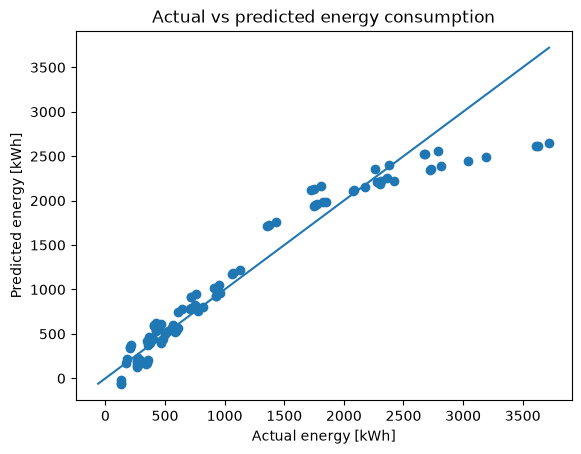

In [13]:
plt.figure()

plt.scatter(
    test["energy_kwh"],
    test["predicted_energy_kwh"]
)

minimum = min(
    test["energy_kwh"].min(),
    test["predicted_energy_kwh"].min()
)

maximum = max(
    test["energy_kwh"].max(),
    test["predicted_energy_kwh"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual energy [kWh]")
plt.ylabel("Predicted energy [kWh]")
plt.title("Actual vs predicted energy consumption")

plt.show()

## Step 5: Error check

The mean and median relative errors should be checked to see where the residuals are clustered at

In [15]:
test["absolute_error"] = (
    test["energy_kwh"] - test["predicted_energy_kwh"]
).abs()

test["relative_error_pct"] = (
    test["absolute_error"]
    / test["energy_kwh"]
    * 100
)

worst = (
    test[
        [
            "route_name",
            "composition_id",
            "energy_kwh",
            "predicted_energy_kwh",
            "absolute_error",
            "relative_error_pct",
            "distance_km",
            "weight_t",
            "v_max_kmh"
        ]
    ]
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

print(worst)

              route_name composition_id  energy_kwh  predicted_energy_kwh  \
119  332/1372 = 333/1373     NEW-BAL-14        3721           2647.832404   
116  332/1372 = 333/1373     REF-BUD-12        3627           2616.638755   
117  332/1372 = 333/1373    REF-PREM-12        3610           2611.075416   
115  332/1372 = 333/1373   REF-COUCH-10        3191           2485.394532   
114  332/1372 = 333/1373      REF-BAL-9        3040           2446.451160   
103    320/324 = 321/325     NEW-BAL-14        2813           2384.247489   
353  NJ 40421 = NJ 40490    REF-COUCH-6        1728           2118.934152   
352  NJ 40421 = NJ 40490      REF-BUD-6        1749           2131.957423   
100    320/324 = 321/325     REF-BUD-12        2732           2353.053840   
101    320/324 = 321/325    REF-PREM-12        2720           2347.490501   

     absolute_error  relative_error_pct  distance_km  weight_t  v_max_kmh  
119     1073.167596           28.840838        442.8     627.6        230  


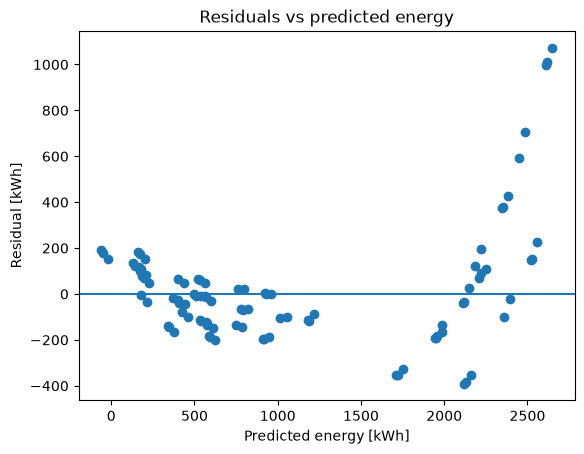

In [16]:
# residual plot

test["residual"] = (
    test["energy_kwh"]
    - test["predicted_energy_kwh"]
)

plt.figure()

plt.scatter(
    test["predicted_energy_kwh"],
    test["residual"]
)

plt.axhline(0)

plt.xlabel("Predicted energy [kWh]")
plt.ylabel("Residual [kWh]")
plt.title("Residuals vs predicted energy")

plt.show()

## Step 6: Improving the models

In this step

### Variant 1

This is the original model

In [18]:
model_1 = smf.ols(
    """
    energy_kwh
    ~ distance_km
    + weight_t
    + v_max_kmh
    """,
    data=train
).fit()

### Variant 2

In this variant, instead of treating distance and weight as separate variables, the product of these two is taken as a single variable for the equation as an interaction term.

In [19]:
model_2 = smf.ols(
    """
    energy_kwh
    ~ distance_km * weight_t
    + v_max_kmh
    """,
    data=train
).fit()

### Variant 3

This variant accounts for non-linearity by converting the distance into a quadratic term

In [21]:
model_3 = smf.ols(
    """
    energy_kwh
    ~ distance_km
    + I(distance_km ** 2)
    + weight_t
    + v_max_kmh
    """,
    data=train
).fit()

### Variant 4

This combines Variants 2 and 3 with both the interaction and quadratic terms

In [22]:
model_4 = smf.ols(
    """
    energy_kwh
    ~ distance_km
    + I(distance_km ** 2)
    + weight_t
    + distance_km:weight_t
    + v_max_kmh
    """,
    data=train
).fit()

## Evaluating the refined models

In [23]:
models = {
    "initial": model_1,
    "interaction": model_2,
    "quadratic": model_3,
    "interaction + quadratic": model_4
}

results = []

for name, model in models.items():

    pred = model.predict(test)

    mae = mean_absolute_error(
        test["energy_kwh"],
        pred
    )

    rmse = mean_squared_error(
        test["energy_kwh"],
        pred
    ) ** 0.5

    r2 = r2_score(
        test["energy_kwh"],
        pred
    )

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

print(results_df)

                     model         MAE        RMSE        R2
0                  initial  166.053617  258.411676  0.927486
1              interaction  114.808938  194.537813  0.958904
2                quadratic  170.176933  256.426870  0.928596
3  interaction + quadratic  120.094701  191.802947  0.960051
